In [1]:
import pandas as pd

In [2]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
df = pd.read_csv(r"C:\Users\wirnk\Downloads\student_performance_eda.csv")
df

,Student_ID,Gender,Age,Attendance_Percent,Study_Hours_Per_Week,Previous_Score,Mathematics_Score,Computer_Science_Score,Average_Score,Passed
0,STU001,Male,16,80.0,12.3,65.0,75.0,65.0,70.0,Yes
1,STU002,Female,16,89.0,3.5,68.0,42.0,53.0,47.5,No
2,STU003,Male,14,97.0,13.4,76.0,66.0,82.0,74.0,Yes
3,STU004,Male,16,83.0,4.6,95.0,66.0,61.0,63.5,Yes
4,STU005,Male,18,96.0,3.7,68.0,54.0,64.0,59.0,Yes
...,...,...,...,...,...,...,...,...,...,...
147,STU148,Male,16,67.0,9.8,29.0,29.0,41.0,35.0,No
148,STU149,Male,17,83.0,8.8,30.0,35.0,50.0,42.5,No
149,STU150,Female,17,77.0,10.8,85.0,64.0,61.0,62.5,Yes
150,STU011,Male,17,61.0,7.7,93.0,54.0,48.0,51.0,Yes


In [4]:
df.head()

,Student_ID,Gender,Age,Attendance_Percent,Study_Hours_Per_Week,Previous_Score,Mathematics_Score,Computer_Science_Score,Average_Score,Passed
0,STU001,Male,16,80.0,12.3,65.0,75.0,65.0,70.0,Yes
1,STU002,Female,16,89.0,3.5,68.0,42.0,53.0,47.5,No
2,STU003,Male,14,97.0,13.4,76.0,66.0,82.0,74.0,Yes
3,STU004,Male,16,83.0,4.6,95.0,66.0,61.0,63.5,Yes
4,STU005,Male,18,96.0,3.7,68.0,54.0,64.0,59.0,Yes


In [5]:
df.shape

(152, 10)

In [6]:
df.columns

Index(['Student_ID', 'Gender', 'Age', 'Attendance_Percent',
       'Study_Hours_Per_Week', 'Previous_Score', 'Mathematics_Score',
       'Computer_Science_Score', 'Average_Score', 'Passed'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Student_ID              152 non-null    object 
 1   Gender                  152 non-null    object 
 2   Age                     152 non-null    int64  
 3   Attendance_Percent      150 non-null    float64
 4   Study_Hours_Per_Week    149 non-null    float64
 5   Previous_Score          152 non-null    float64
 6   Mathematics_Score       152 non-null    float64
 7   Computer_Science_Score  152 non-null    float64
 8   Average_Score           152 non-null    float64
 9   Passed                  152 non-null    object 
dtypes: float64(6), int64(1), object(3)
memory usage: 12.0+ KB


In [8]:
df.describe()

,Age,Attendance_Percent,Study_Hours_Per_Week,Previous_Score,Mathematics_Score,Computer_Science_Score,Average_Score
count,152.000000,150.000000,149.000000,152.000000,152.000000,152.000000,152.000000
mean,16.427632,81.533333,7.961074,66.355263,56.592105,53.368421,54.980263
std,1.685945,10.724535,3.591840,16.956668,13.611621,14.287346,11.317056
min,14.000000,54.000000,1.000000,29.000000,21.000000,4.000000,26.000000
25%,15.000000,74.250000,5.400000,57.000000,47.000000,46.000000,47.500000
50%,16.000000,82.000000,7.800000,68.000000,56.000000,53.000000,54.750000
75%,18.000000,89.000000,10.300000,76.000000,66.000000,63.250000,62.500000
max,19.000000,100.000000,19.400000,98.000000,100.000000,94.000000,89.500000


Find missing values

In [9]:
df.isnull().sum()

Student_ID                0
Gender                    0
Age                       0
Attendance_Percent        2
Study_Hours_Per_Week      3
Previous_Score            0
Mathematics_Score         0
Computer_Science_Score    0
Average_Score             0
Passed                    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(2)

In [11]:
df["Gender"].value_counts()

Gender
Female    82
Male      70
Name: count, dtype: int64

In [12]:
df["Passed"].value_counts()

Passed
Yes    100
No      52
Name: count, dtype: int64

Calculate the %

In [13]:
df["Passed"].value_counts(normalize=True)*100

Passed
Yes    65.789474
No     34.210526
Name: proportion, dtype: float64

1. Does student attndance affect performance
2. Do students who put in more hours achieve better results
3. is the previous academic perfomance to current perfomance
4. Is maths perfomance different from Csc
5. What characteristics distinguish students who passed from those who fail

Lesson 2: Data cleaning with Pandas

In [14]:
clean_df = df.copy()

In [15]:
clean_df.duplicated().sum()

np.int64(2)

In [16]:
clean_df[clean_df.duplicated()]

,Student_ID,Gender,Age,Attendance_Percent,Study_Hours_Per_Week,Previous_Score,Mathematics_Score,Computer_Science_Score,Average_Score,Passed
150,STU011,Male,17,61.0,7.7,93.0,54.0,48.0,51.0,Yes
151,STU059,Male,17,79.0,12.6,70.0,73.0,72.0,72.5,Yes


In [17]:
clean_df = clean_df.drop_duplicates()

In [18]:
clean_df.duplicated().sum()

np.int64(0)

In [19]:
clean_df.shape

(150, 10)

Chech for missing values

In [20]:
clean_df.isnull().sum()

Student_ID                0
Gender                    0
Age                       0
Attendance_Percent        2
Study_Hours_Per_Week      3
Previous_Score            0
Mathematics_Score         0
Computer_Science_Score    0
Average_Score             0
Passed                    0
dtype: int64

In [21]:
(clean_df.isnull().sum()/len(clean_df))*100

Student_ID                0.000000
Gender                    0.000000
Age                       0.000000
Attendance_Percent        1.333333
Study_Hours_Per_Week      2.000000
Previous_Score            0.000000
Mathematics_Score         0.000000
Computer_Science_Score    0.000000
Average_Score             0.000000
Passed                    0.000000
dtype: float64

Handling Missing values

In [22]:
#chech for the median

In [23]:
clean_df["Attendance_Percent"].median()

82.0

In [24]:
clean_df["Study_Hours_Per_Week"].median()

7.8

#fill missing value using fillna

In [25]:
clean_df["Attendance_Percent"] = clean_df["Attendance_Percent"].fillna(clean_df["Attendance_Percent"].median())

In [26]:
clean_df["Study_Hours_Per_Week"] = clean_df["Study_Hours_Per_Week"].fillna(clean_df["Study_Hours_Per_Week"].median())

In [27]:
clean_df.isnull().sum()

Student_ID                0
Gender                    0
Age                       0
Attendance_Percent        0
Study_Hours_Per_Week      0
Previous_Score            0
Mathematics_Score         0
Computer_Science_Score    0
Average_Score             0
Passed                    0
dtype: int64

In [28]:
clean_df.dtypes

Student_ID                 object
Gender                     object
Age                         int64
Attendance_Percent        float64
Study_Hours_Per_Week      float64
Previous_Score            float64
Mathematics_Score         float64
Computer_Science_Score    float64
Average_Score             float64
Passed                     object
dtype: object

In [29]:
clean_df

,Student_ID,Gender,Age,Attendance_Percent,Study_Hours_Per_Week,Previous_Score,Mathematics_Score,Computer_Science_Score,Average_Score,Passed
0,STU001,Male,16,80.0,12.3,65.0,75.0,65.0,70.0,Yes
1,STU002,Female,16,89.0,3.5,68.0,42.0,53.0,47.5,No
2,STU003,Male,14,97.0,13.4,76.0,66.0,82.0,74.0,Yes
3,STU004,Male,16,83.0,4.6,95.0,66.0,61.0,63.5,Yes
4,STU005,Male,18,96.0,3.7,68.0,54.0,64.0,59.0,Yes
...,...,...,...,...,...,...,...,...,...,...
145,STU146,Male,15,72.0,6.6,79.0,71.0,43.0,57.0,Yes
146,STU147,Male,16,75.0,12.0,74.0,70.0,55.0,62.5,Yes
147,STU148,Male,16,67.0,9.8,29.0,29.0,41.0,35.0,No
148,STU149,Male,17,83.0,8.8,30.0,35.0,50.0,42.5,No


In [30]:
clean_df.describe()

,Age,Attendance_Percent,Study_Hours_Per_Week,Previous_Score,Mathematics_Score,Computer_Science_Score,Average_Score
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,16.420000,81.693333,7.928667,66.153333,56.500000,53.280000,54.890000
std,1.695909,10.588677,3.559397,16.926107,13.634613,14.294656,11.296919
min,14.000000,54.000000,1.000000,29.000000,21.000000,4.000000,26.000000
25%,15.000000,75.000000,5.425000,57.000000,47.000000,46.000000,47.500000
50%,16.000000,82.000000,7.800000,68.000000,56.000000,53.000000,54.750000
75%,18.000000,89.000000,10.100000,76.000000,66.000000,63.000000,62.375000
max,19.000000,100.000000,19.400000,98.000000,100.000000,94.000000,89.500000


In [31]:
clean_df["Gender"].unique()

array(['Male', 'Female'], dtype=object)

In [32]:
clean_df["Passed"].unique()

array(['Yes', 'No'], dtype=object)

In [33]:
clean_df["Age"].min()

14

In [34]:
clean_df["Age"].max()

19

In [35]:
clean_df["Attendance_Percent"].min()

54.0

In [36]:
clean_df["Attendance_Percent"].max()

100.0

In [37]:
clean_df[(clean_df["Mathematics_Score"] < 0) | (clean_df["Mathematics_Score"] > 100)]

,Student_ID,Gender,Age,Attendance_Percent,Study_Hours_Per_Week,Previous_Score,Mathematics_Score,Computer_Science_Score,Average_Score,Passed


In [38]:
clean_df[(clean_df["Mathematics_Score"] < 0) | (clean_df["Mathematics_Score"]>100)]

,Student_ID,Gender,Age,Attendance_Percent,Study_Hours_Per_Week,Previous_Score,Mathematics_Score,Computer_Science_Score,Average_Score,Passed


In [39]:
clean_df[(clean_df["Computer_Science_Score"] < 0) | (clean_df["Computer_Science_Score"]>100)]

,Student_ID,Gender,Age,Attendance_Percent,Study_Hours_Per_Week,Previous_Score,Mathematics_Score,Computer_Science_Score,Average_Score,Passed


In [40]:
df.describe()

,Age,Attendance_Percent,Study_Hours_Per_Week,Previous_Score,Mathematics_Score,Computer_Science_Score,Average_Score
count,152.000000,150.000000,149.000000,152.000000,152.000000,152.000000,152.000000
mean,16.427632,81.533333,7.961074,66.355263,56.592105,53.368421,54.980263
std,1.685945,10.724535,3.591840,16.956668,13.611621,14.287346,11.317056
min,14.000000,54.000000,1.000000,29.000000,21.000000,4.000000,26.000000
25%,15.000000,74.250000,5.400000,57.000000,47.000000,46.000000,47.500000
50%,16.000000,82.000000,7.800000,68.000000,56.000000,53.000000,54.750000
75%,18.000000,89.000000,10.300000,76.000000,66.000000,63.250000,62.500000
max,19.000000,100.000000,19.400000,98.000000,100.000000,94.000000,89.500000


In [41]:
Q1 = clean_df["Mathematics_Score"].quantile(0.25)
Q3 = clean_df["Mathematics_Score"].quantile(0.75)

IQR = Q3 -Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(Q1)
print(Q3)
print(IQR)
print(lower_bound)
print(upper_bound)

47.0
66.0
19.0
18.5
94.5


In [42]:
math_outliers = clean_df[(clean_df["Mathematics_Score"] < lower_bound) |(clean_df["Mathematics_Score"]> upper_bound)]
math_outliers

,Student_ID,Gender,Age,Attendance_Percent,Study_Hours_Per_Week,Previous_Score,Mathematics_Score,Computer_Science_Score,Average_Score,Passed
20,STU021,Female,14,92.0,11.7,71.0,100.0,62.0,81.0,Yes


In [43]:
def detect_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column]< lower_bound) | (data[column]> upper_bound)]
    return outliers

In [44]:
detect_outliers(clean_df, "Mathematics_Score")

,Student_ID,Gender,Age,Attendance_Percent,Study_Hours_Per_Week,Previous_Score,Mathematics_Score,Computer_Science_Score,Average_Score,Passed
20,STU021,Female,14,92.0,11.7,71.0,100.0,62.0,81.0,Yes


In [45]:
detect_outliers(clean_df, "Computer_Science_Score")

,Student_ID,Gender,Age,Attendance_Percent,Study_Hours_Per_Week,Previous_Score,Mathematics_Score,Computer_Science_Score,Average_Score,Passed
75,STU076,Female,14,62.0,3.0,55.0,48.0,4.0,26.0,No
105,STU106,Female,14,75.0,2.4,66.0,37.0,16.0,26.5,No
143,STU144,Female,17,95.0,16.9,87.0,85.0,94.0,89.5,Yes


In [46]:
print("Rows:", clean_df.shape[0])
print("Columns:",clean_df.shape[1])

print("Missing Values:")
print(clean_df.isnull().sum())

print("Duplicates:")
print(clean_df.duplicated().sum())

print("Unique Student IDs:")
print(clean_df["Student_ID"].nunique())

Rows: 150
Columns: 10
Missing Values:
Student_ID                0
Gender                    0
Age                       0
Attendance_Percent        0
Study_Hours_Per_Week      0
Previous_Score            0
Mathematics_Score         0
Computer_Science_Score    0
Average_Score             0
Passed                    0
dtype: int64
Duplicates:
0
Unique Student IDs:
150


In [47]:
clean_df.to_csv("student_performance_clean.csv",index=False)

In [48]:
import os
print(os.getcwd())

C:\Users\wirnk


In [49]:
df.head()

,Student_ID,Gender,Age,Attendance_Percent,Study_Hours_Per_Week,Previous_Score,Mathematics_Score,Computer_Science_Score,Average_Score,Passed
0,STU001,Male,16,80.0,12.3,65.0,75.0,65.0,70.0,Yes
1,STU002,Female,16,89.0,3.5,68.0,42.0,53.0,47.5,No
2,STU003,Male,14,97.0,13.4,76.0,66.0,82.0,74.0,Yes
3,STU004,Male,16,83.0,4.6,95.0,66.0,61.0,63.5,Yes
4,STU005,Male,18,96.0,3.7,68.0,54.0,64.0,59.0,Yes


In [50]:
df = pd.read_csv("student_performance_clean.csv")

In [51]:
df.head()

,Student_ID,Gender,Age,Attendance_Percent,Study_Hours_Per_Week,Previous_Score,Mathematics_Score,Computer_Science_Score,Average_Score,Passed
0,STU001,Male,16,80.0,12.3,65.0,75.0,65.0,70.0,Yes
1,STU002,Female,16,89.0,3.5,68.0,42.0,53.0,47.5,No
2,STU003,Male,14,97.0,13.4,76.0,66.0,82.0,74.0,Yes
3,STU004,Male,16,83.0,4.6,95.0,66.0,61.0,63.5,Yes
4,STU005,Male,18,96.0,3.7,68.0,54.0,64.0,59.0,Yes


In [52]:
df.shape

(150, 10)

In [53]:
df.describe()

,Age,Attendance_Percent,Study_Hours_Per_Week,Previous_Score,Mathematics_Score,Computer_Science_Score,Average_Score
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,16.420000,81.693333,7.928667,66.153333,56.500000,53.280000,54.890000
std,1.695909,10.588677,3.559397,16.926107,13.634613,14.294656,11.296919
min,14.000000,54.000000,1.000000,29.000000,21.000000,4.000000,26.000000
25%,15.000000,75.000000,5.425000,57.000000,47.000000,46.000000,47.500000
50%,16.000000,82.000000,7.800000,68.000000,56.000000,53.000000,54.750000
75%,18.000000,89.000000,10.100000,76.000000,66.000000,63.000000,62.375000
max,19.000000,100.000000,19.400000,98.000000,100.000000,94.000000,89.500000


In [54]:
df["Average_Score"].describe()

count    150.000000
mean      54.890000
std       11.296919
min       26.000000
25%       47.500000
50%       54.750000
75%       62.375000
max       89.500000
Name: Average_Score, dtype: float64

In [55]:
print("mean", df["Average_Score"].mean())

mean 54.89


In [56]:
print("median", df["Average_Score"].median())

median 54.75


In [57]:
print("min", df["Average_Score"].min())

min 26.0


In [58]:
df["Passed"].value_counts(normalize=True)*100

Passed
Yes    65.333333
No     34.666667
Name: proportion, dtype: float64

In [59]:
print("Average Mathematics score:",df["Mathematics_Score"].mean())
print("Average Computer Science score:",df["Computer_Science_Score"].mean())

Average Mathematics score: 56.5
Average Computer Science score: 53.28


In [60]:
subject_Average = df[["Mathematics_Score","Computer_Science_Score"]].mean()

In [61]:
print(subject_Average)

Mathematics_Score         56.50
Computer_Science_Score    53.28
dtype: float64


Is there a meanigful difference Mathematics and Computer

Investigating Attendance is an important aspect of this data

In [62]:
df["Attendance_Percent"].describe()

count    150.000000
mean      81.693333
std       10.588677
min       54.000000
25%       75.000000
50%       82.000000
75%       89.000000
max      100.000000
Name: Attendance_Percent, dtype: float64

In [63]:
df.groupby("Passed")["Attendance_Percent"].mean()

Passed
No     79.115385
Yes    83.061224
Name: Attendance_Percent, dtype: float64

In [64]:
def attendance_group(value):
    if value < 70:
        return "low"
    elif value < 85:
        return "medium"
    else:
        return "High"

In [65]:
df["Attendance_Group"] = df["Attendance_Percent"].apply(attendance_group)

In [66]:
df["Attendance_Group"].value_counts()

Attendance_Group
medium    74
High      58
low       18
Name: count, dtype: int64

In [67]:
df.groupby("Attendance_Group")["Average_Score"].mean()

Attendance_Group
High      58.275862
low       47.083333
medium    54.135135
Name: Average_Score, dtype: float64

Study vs Performance

In [68]:
df["Study_Hours_Per_Week"].describe()

count    150.000000
mean       7.928667
std        3.559397
min        1.000000
25%        5.425000
50%        7.800000
75%       10.100000
max       19.400000
Name: Study_Hours_Per_Week, dtype: float64

In [69]:
df.groupby("Passed")["Study_Hours_Per_Week"].mean()

Passed
No     5.973077
Yes    8.966327
Name: Study_Hours_Per_Week, dtype: float64

Create study hours category

In [70]:
def study_group(hours):
    if hours < 5:
        return "Low"
    elif hours < 10:
        return "Medium"
    else:
        return "High"

In [71]:
df["Study_Group"] = df["Study_Hours_Per_Week"].apply(study_group)
df["Study_Group"].value_counts()

Study_Group
Medium    82
High      39
Low       29
Name: count, dtype: int64

In [72]:
df.head()

,Student_ID,Gender,Age,Attendance_Percent,Study_Hours_Per_Week,Previous_Score,Mathematics_Score,Computer_Science_Score,Average_Score,Passed,Attendance_Group,Study_Group
0,STU001,Male,16,80.0,12.3,65.0,75.0,65.0,70.0,Yes,medium,High
1,STU002,Female,16,89.0,3.5,68.0,42.0,53.0,47.5,No,High,Low
2,STU003,Male,14,97.0,13.4,76.0,66.0,82.0,74.0,Yes,High,High
3,STU004,Male,16,83.0,4.6,95.0,66.0,61.0,63.5,Yes,medium,Low
4,STU005,Male,18,96.0,3.7,68.0,54.0,64.0,59.0,Yes,High,Low


In [73]:
df.groupby("Study_Group")["Average_Score"].mean()

Study_Group
High      62.807692
Low       45.189655
Medium    54.554878
Name: Average_Score, dtype: float64

In [74]:
df[["Previous_Score", "Average_Score"]].corr()

,Previous_Score,Average_Score
Previous_Score,1.000000,0.441794
Average_Score,0.441794,1.000000


In [75]:
correlation = df.corr(numeric_only=True)
print(correlation)

                             Age  Attendance_Percent  Study_Hours_Per_Week  \
Age                     1.000000            0.057302             -0.055709   
Attendance_Percent      0.057302            1.000000             -0.020867   
Study_Hours_Per_Week   -0.055709           -0.020867              1.000000   
Previous_Score          0.178707            0.032431             -0.087767   
Mathematics_Score      -0.016399            0.141273              0.393639   
Computer_Science_Score  0.105578            0.301109              0.456156   
Average_Score           0.056901            0.275759              0.526148   

                        Previous_Score  Mathematics_Score  \
Age                           0.178707          -0.016399   
Attendance_Percent            0.032431           0.141273   
Study_Hours_Per_Week         -0.087767           0.393639   
Previous_Score                1.000000           0.429691   
Mathematics_Score             0.429691           1.000000   
Computer_

In [76]:
correlation["Average_Score"].sort_values(ascending=True)

Age                       0.056901
Attendance_Percent        0.275759
Previous_Score            0.441794
Study_Hours_Per_Week      0.526148
Mathematics_Score         0.798627
Computer_Science_Score    0.818829
Average_Score             1.000000
Name: Average_Score, dtype: float64

It tell us which numerical values have the strongest relationship with academic perfomance

In [77]:
top_students = df.sort_values(
    by="Average_Score", ascending=False
).head(10)

top_students[[
    "Student_ID",
    "Average_Score",
    "Attendance_Percent",
    "Study_Hours_Per_Week"
]

]

,Student_ID,Average_Score,Attendance_Percent,Study_Hours_Per_Week
143,STU144,89.5,95.0,16.9
72,STU073,86.5,87.0,10.9
20,STU021,81.0,92.0,11.7
18,STU019,79.0,79.0,6.7
24,STU025,78.0,80.0,12.0
97,STU098,75.5,87.0,13.6
2,STU003,74.0,97.0,13.4
29,STU030,74.0,82.0,19.4
58,STU059,72.5,79.0,12.6
56,STU057,72.0,86.0,8.7


Find students who may need help

Business and educational purposes

In [78]:
at_risk =df[ df["Average_Score"]<50]

In [79]:
len(at_risk)

52

In [80]:
at_risk[
[
    "Student_ID",
    "Attendance_Percent",
    "Study_Hours_Per_Week",
    "Computer_Science_Score",
    "Average_Score"
]
    ]

,Student_ID,Attendance_Percent,Study_Hours_Per_Week,Computer_Science_Score,Average_Score
1,STU002,89.0,3.5,53.0,47.5
9,STU010,91.0,7.4,28.0,48.0
15,STU016,72.0,1.4,28.0,37.0
19,STU020,95.0,6.1,44.0,42.0
22,STU023,82.0,2.6,49.0,41.5
28,STU029,66.0,6.9,53.0,47.0
30,STU031,98.0,2.6,54.0,45.5
31,STU032,73.0,5.1,45.0,43.0
36,STU037,66.0,5.0,44.0,39.0
37,STU038,91.0,8.0,36.0,48.0


In [81]:
high_risk_students = df[
    (df["Average_Score"]<50) &
    (df["Attendance_Percent"]<75)
    ]

In [82]:
high_risk_students[[
    "Student_ID",
    "Attendance_Percent",
    "Study_Hours_Per_Week",
    "Average_Score"
]]

,Student_ID,Attendance_Percent,Study_Hours_Per_Week,Average_Score
15,STU016,72.0,1.4,37.0
28,STU029,66.0,6.9,47.0
31,STU032,73.0,5.1,43.0
36,STU037,66.0,5.0,39.0
42,STU043,59.0,14.3,47.5
43,STU044,72.0,9.4,45.5
55,STU056,59.0,9.6,45.0
62,STU063,54.0,4.4,32.0
67,STU068,69.0,2.8,36.5
69,STU070,73.0,9.7,49.0


Gender comparison

In [83]:
df.groupby("Gender")["Average_Score"].mean()

Gender
Female    54.737805
Male      55.073529
Name: Average_Score, dtype: float64

In [84]:
df.groupby("Gender")[["Mathematics_Score", "Computer_Science_Score"]].mean()

,Mathematics_Score,Computer_Science_Score
Gender,,
Female,56.609756,52.865854
Male,56.367647,53.779412


In [85]:
pd.crosstab(df["Gender"],df["Passed"])

Passed,No,Yes
Gender,,
Female,29,53
Male,23,45


In [86]:
pd.crosstab(df["Gender"],df["Passed"],normalize="index")*100

Passed,No,Yes
Gender,,
Female,35.365854,64.634146
Male,33.823529,66.176471


Multiple statistics using aggregated format

In [87]:
df.groupby("Passed")[
    "Attendance_Percent"
    ].agg(["mean","median","min","max"])    

,mean,median,min,max
Passed,,,,
No,79.115385,80.0,54.0,100.0
Yes,83.061224,83.5,57.0,100.0


In [88]:
df.groupby("Passed").agg({
    "Attendance_Percent":"mean",
    "Study_Hours_Per_Week":"mean",
    "Previous_Score":"mean",
    "Average_Score":"mean"
})

,Attendance_Percent,Study_Hours_Per_Week,Previous_Score,Average_Score
Passed,,,,
No,79.115385,5.973077,59.461538,43.240385
Yes,83.061224,8.966327,69.704082,61.071429


EDA summary

In [89]:
summary=df.groupby("Passed").agg({
    "Attendance_Percent":"mean",
    "Study_Hours_Per_Week":"mean",
    "Previous_Score":"mean",
    "Average_Score":"mean",
    "Mathematics_Score":"mean",
    "Computer_Science_Score":"mean"
}).round(2)
summary

,Attendance_Percent,Study_Hours_Per_Week,Previous_Score,Average_Score,Mathematics_Score,Computer_Science_Score
Passed,,,,,,
No,79.12,5.97,59.46,43.24,45.62,40.87
Yes,83.06,8.97,69.70,61.07,62.28,59.87


In [90]:
df.to_csv("student_perfomance_analysis.csv",index=False)

In [91]:
import os
print(os.getcwd())

C:\Users\wirnk


Lesson 4: Data Visualization using EDA using matplotlib

In [92]:
df 

,Student_ID,Gender,Age,Attendance_Percent,Study_Hours_Per_Week,Previous_Score,Mathematics_Score,Computer_Science_Score,Average_Score,Passed,Attendance_Group,Study_Group
0,STU001,Male,16,80.0,12.3,65.0,75.0,65.0,70.0,Yes,medium,High
1,STU002,Female,16,89.0,3.5,68.0,42.0,53.0,47.5,No,High,Low
2,STU003,Male,14,97.0,13.4,76.0,66.0,82.0,74.0,Yes,High,High
3,STU004,Male,16,83.0,4.6,95.0,66.0,61.0,63.5,Yes,medium,Low
4,STU005,Male,18,96.0,3.7,68.0,54.0,64.0,59.0,Yes,High,Low
...,...,...,...,...,...,...,...,...,...,...,...,...
145,STU146,Male,15,72.0,6.6,79.0,71.0,43.0,57.0,Yes,medium,Medium
146,STU147,Male,16,75.0,12.0,74.0,70.0,55.0,62.5,Yes,medium,High
147,STU148,Male,16,67.0,9.8,29.0,29.0,41.0,35.0,No,low,Medium
148,STU149,Male,17,83.0,8.8,30.0,35.0,50.0,42.5,No,medium,Medium


In [93]:
import pandas as pd
import matplotlib.pyplot as plt

In [94]:
pd.read_csv("student_perfomance_analysis.csv")

,Student_ID,Gender,Age,Attendance_Percent,Study_Hours_Per_Week,Previous_Score,Mathematics_Score,Computer_Science_Score,Average_Score,Passed,Attendance_Group,Study_Group
0,STU001,Male,16,80.0,12.3,65.0,75.0,65.0,70.0,Yes,medium,High
1,STU002,Female,16,89.0,3.5,68.0,42.0,53.0,47.5,No,High,Low
2,STU003,Male,14,97.0,13.4,76.0,66.0,82.0,74.0,Yes,High,High
3,STU004,Male,16,83.0,4.6,95.0,66.0,61.0,63.5,Yes,medium,Low
4,STU005,Male,18,96.0,3.7,68.0,54.0,64.0,59.0,Yes,High,Low
...,...,...,...,...,...,...,...,...,...,...,...,...
145,STU146,Male,15,72.0,6.6,79.0,71.0,43.0,57.0,Yes,medium,Medium
146,STU147,Male,16,75.0,12.0,74.0,70.0,55.0,62.5,Yes,medium,High
147,STU148,Male,16,67.0,9.8,29.0,29.0,41.0,35.0,No,low,Medium
148,STU149,Male,17,83.0,8.8,30.0,35.0,50.0,42.5,No,medium,Medium


In [95]:
df.head()

,Student_ID,Gender,Age,Attendance_Percent,Study_Hours_Per_Week,Previous_Score,Mathematics_Score,Computer_Science_Score,Average_Score,Passed,Attendance_Group,Study_Group
0,STU001,Male,16,80.0,12.3,65.0,75.0,65.0,70.0,Yes,medium,High
1,STU002,Female,16,89.0,3.5,68.0,42.0,53.0,47.5,No,High,Low
2,STU003,Male,14,97.0,13.4,76.0,66.0,82.0,74.0,Yes,High,High
3,STU004,Male,16,83.0,4.6,95.0,66.0,61.0,63.5,Yes,medium,Low
4,STU005,Male,18,96.0,3.7,68.0,54.0,64.0,59.0,Yes,High,Low


Histogram helps understand the distribution of numerical data

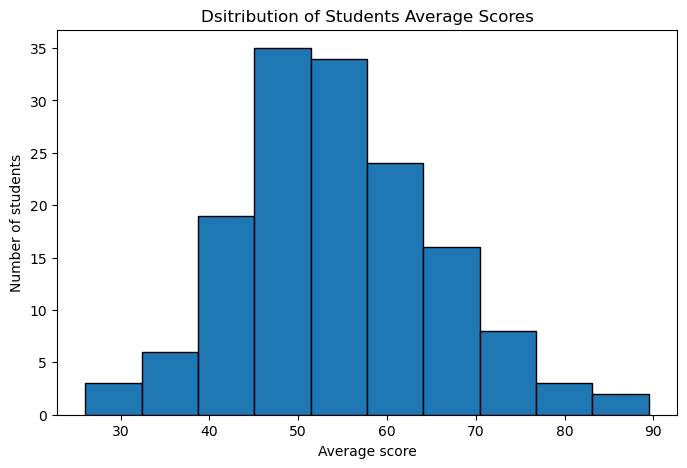

In [96]:
plt.figure(figsize=(8,5))
plt.hist(
    df["Average_Score"],bins=10, edgecolor="black"
)
plt.title("Dsitribution of Students Average Scores")
plt.xlabel("Average score")
plt.ylabel("Number of students")
plt.show()

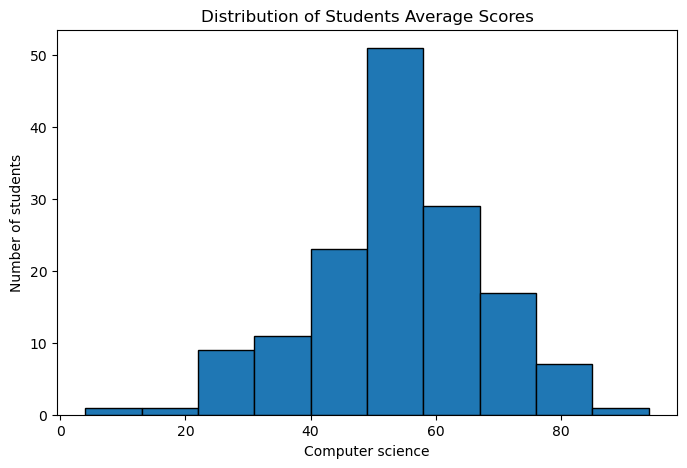

In [97]:
plt.figure(figsize=(8,5))
plt.hist(
    df["Computer_Science_Score"],bins=10, edgecolor="black"
)
plt.title("Distribution of Students Average Scores")
plt.xlabel("Computer science")
plt.ylabel("Number of students")
plt.savefig("Distribution of Students Average Scores")
plt.show()

In [98]:
pass_counts = df["Passed"].value_counts()

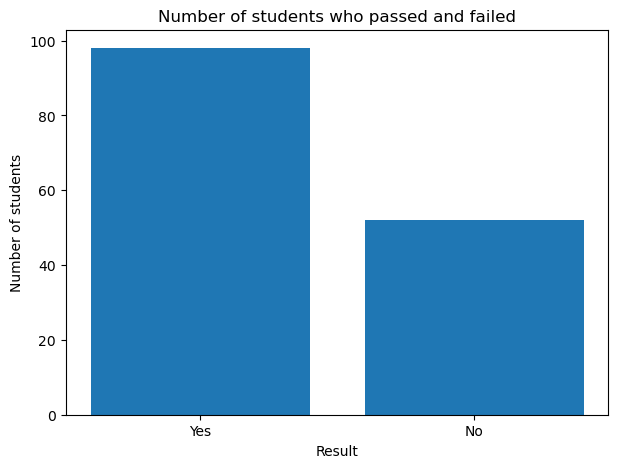

In [99]:
plt.figure(figsize=(7,5))
plt.bar(pass_counts.index,
       pass_counts.values)
plt.title("Number of students who passed and failed")
plt.xlabel("Result")
plt.ylabel("Number of students")
plt.savefig("Number of students who passed and failed")
plt.show()

In [100]:
pass_percentages= (
    df["Passed"].value_counts(normalize=True)*100
)
print(pass_percentages)

Passed
Yes    65.333333
No     34.666667
Name: proportion, dtype: float64


In [101]:
#comparing two scores
subject_average= df[["Mathematics_Score", "Computer_Science_Score"]].mean()

<function matplotlib.pyplot.show(close=None, block=None)>

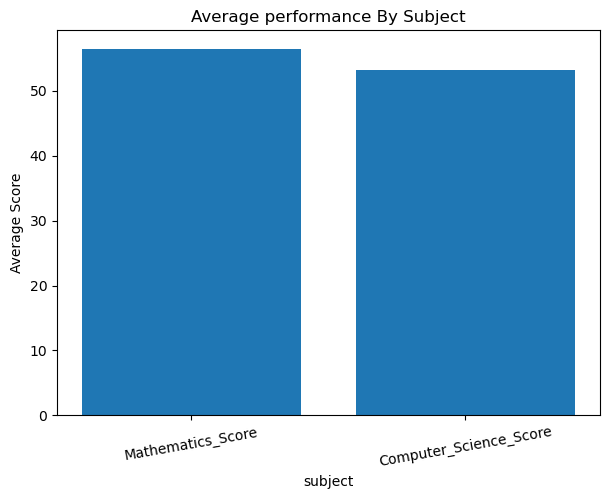

In [102]:
plt.figure(figsize=(7,5))
plt.bar(subject_average.index,
       subject_average.values)
plt.title("Average performance By Subject")
plt.xlabel("subject")
plt.ylabel("Average Score")
plt.xticks(rotation=10)
plt.savefig("Average performance By Subject")
plt.show

Box plot is  extremely useful in EDA. Helps to identify the mean, spread, quartiles
potential outliers

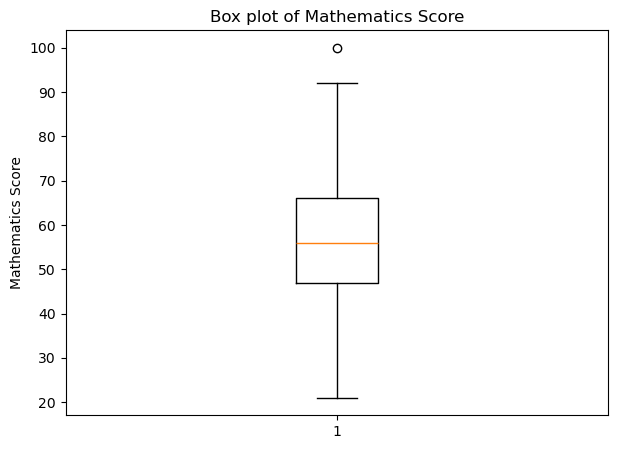

In [103]:
plt.figure(figsize=(7,5))
plt.boxplot(
    df["Mathematics_Score"]
)
plt.title("Box plot of Mathematics Score")
plt.ylabel("Mathematics Score")
plt.savefig("Box plot of Mathematics Score")
plt.show()

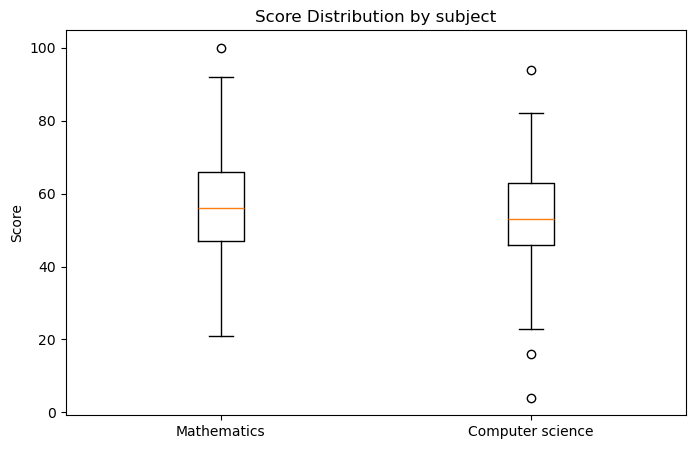

In [104]:
plt.figure(figsize=(8,5))
plt.boxplot([df["Mathematics_Score"],
            df["Computer_Science_Score"]],
            tick_labels=["Mathematics","Computer science"])

plt.title("Score Distribution by subject")
plt.ylabel("Score")
plt.savefig("Score Distribution by subject")
plt.show()

Attendance vs average score

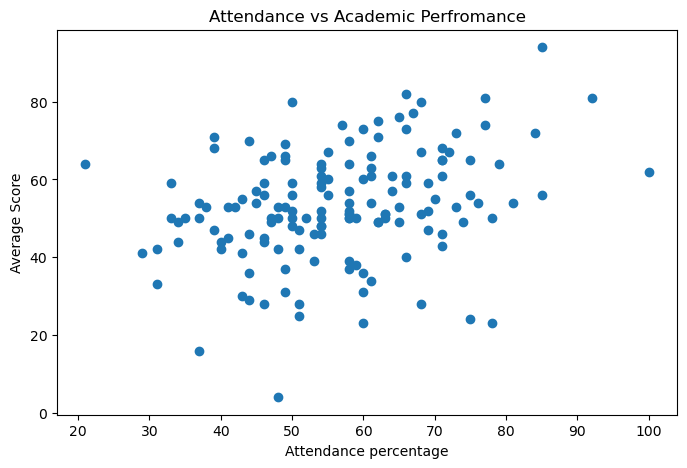

In [105]:
plt.figure(figsize=(8,5))
plt.scatter(
    df["Mathematics_Score"],
    df["Computer_Science_Score"]
)
plt.title("Attendance vs Academic Perfromance")
plt.xlabel("Attendance percentage")
plt.ylabel("Average Score")
plt.savefig("Attendancs Vs Academic Performance")
plt.show()

In [106]:
import matplotlib.pyplot as plt

Calculation the correlation

In [107]:
attendance_correlation= df["Attendance_Percent"].corr(df["Average_Score"])
print(attendance_correlation)

0.27575934319060985


Visual evidence + numerical evidence

In [108]:
study_hour vs performance

SyntaxError: invalid syntax (4037983472.py, line 1)

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.scatter(
    df["Mathematics_Score"],
    df["Computer_Science_Score"]
)
plt.title("Attendance vs Academic Perfromance")
plt.xlabel("Attendance percentage")
plt.ylabel("Average Score")
plt.savefig("Attendace vs Academic Performance")
plt.show()

In [ ]:
study_correlation =df["Study_Hours_Per_Week"].corr(df["Average_Score"])
print(study_correlation)

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df["Previous_Score"],
           df["Average_Score"])
plt.title("Previous Performance vs Current Performance")
plt.xlabel("Previous Score")
plt.ylabel("Current average Score")
plt.show()


In [ ]:
previous_corr = df["Previous_Score"].corr(df["Average_Score"])
print(previous_corr)

In [ ]:
passed_attendance = df[df["Passed"]=="Yes"]["Attendance_Percent"]
failed_attendance = df[df["Passed"]=="No"]["Attendance_Percent"]

In [ ]:
plt.figure(figsize=(8,5))
plt.boxplot([
    passed_attendance,
    failed_attendance
],
           tick_labels =[
               "Passed",
               "Failed"
           ]
           )
plt.title("Attendance Distribution by Student Result")
plt.ylabel("Attendance Percentage")

plt.show()

In [ ]:
passed_study = df[df["Passed"]=="Yes"]["Study_Hours_Per_Week"]
failed_study = df[df["Passed"]=="No"]["Study_Hours_Per_Week"]

In [ ]:
plt.figure(figsize=(8,5))
plt.boxplot([
    passed_study,
    failed_study
], tick_labels=[
    "Passed",
    "Failed"
])
plt.title("Study Hours by student result")
plt.ylabel("Student Hours Per Week")
plt.show()

In [ ]:
def aatendace_group(values):
    if value < 70:
        return "low"
    elif value < 85:
        return "medium"
    else:
        return "High"

In [ ]:
df["Attendance_Group"] = df["Attendance_Percent"].apply(attendance_group)

In [ ]:
attendance_performance = df.groupby(
    "Attendance_Group"
)["Average_Score"].mean()

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(
    attendance_performance.index,
    attendance_performance.values
)
plt.title("Average Score by Attendance Group")
plt.xlabel("Attendance Group")
plt.ylabel("Average Score")
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(
    attendance_performance.index,
    attendance_performance.values,
    color=["green","blue","red"]
)
plt.title("Average Score by Attendance Group")
plt.xlabel("Attendance Group")
plt.ylabel("Average Score")
plt.show()

study Hours category

In [ ]:
def study_group(hours):
    if hours < 5:
        return "Low"
    elif hours < 10 :
        return "Medium"
    else:
        return "High"

In [ ]:
df["Study_Group"] = df["Study_Hours_Per_Week"].apply(study_group)

In [ ]:
study_performance = df.groupby("Study_Group")["Average_Score"].mean()

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(
    study_performance.index,
    study_performance.values,
    color=["Red","Green","Blue"]
)
plt.title("Average Performance by Study Group")
plt.xlabel('Study Group')
plt.ylabel("Average Score")
plt.show()


correlation matrix

In [ ]:
numeric_df = df.select_dtypes(include = "number")
correlation_matrix = numeric_df.corr()
print(correlation_matrix)

In [ ]:
plt.figure(figsize=(8,5))
plt.imshow(
    correlation_matrix,
    aspect="auto"
)
plt.colorbar()
plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)
plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10,8))
plt.imshow(
    correlation_matrix,
    aspect="auto"
)
plt.colorbar()
columns= correlation_matrix.columns
plt.xticks(
    range(len(columns)),
    columns,
    rotation = 90,
)
plt.yticks(
    range(len(columns)),
    columns
)
for i in range(len(columns)):
    for j in range(len(columns)):
        value = correlation_matrix.iloc[i,j]
        plt.text(
            j,
            i,
            f"{value:2f}",
            ha = "center",
            va = "center"
            
        )
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [ ]:
performance_correlation= (
    correlation_matrix["Average_Score"].sort_values(ascending=False)
)
print(performance_correlation)

In [ ]:
at_risk = df[df["Average_Score"] < 50]

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(
    df["Attendance_Percent"],
    df["Average_Score"],
    label ="All Students"
)

plt.scatter(
    at_risk["Attendance_Percent"],
    at_risk["Average_Score"],
    label = "At Risk"
)
plt.axhline(
    y=50,
    linestyle="--"
)
plt.title("Attendance and students at Academic Risk")
plt.xlabel("Attendance Percentage")
plt.ylabel("Average Score")
plt.legend()
plt.show()

Performance Category

In [ ]:
def performance_category(score):
    if score < 50:
        return "At Risk"
    elif score < 70:
        return "Average"
    else:
        return "High Perfomance"

In [ ]:
df["Performance_Category"] = df["Average_Score"].apply(performance_category)

In [ ]:
df["Performance_Category"].value_counts()

In [ ]:
performance_counts = df["Performance_Category"].value_counts()

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(
    performance_counts.index,
    performance_counts.values,
    color=["Red","Black","pink"]
)
plt.title("Student Performance")
plt.xlabel("Performance Category")
plt.ylabel("NUmber of students")
plt.show()
    

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(
    df["Attendance_Percent"],
    df["Average_Score"]
)
plt.title("Attendance Vs Student Performance")
plt.xlabel("Attendance Performance")
plt.ylabel("Average_Score")
plt.savefig(
    "attendance_vs_performance.png",
    bbox_inches="tight"
)
plt.show()

STATISTICS FOR EDA
mean+median+mode+stand. dev+ percentiles+ correlation+ covariance+z-score, cconfidence interval+ hypothesis testing+p-value

In [110]:
import numpy as np
df = pd.read_csv("student_performance_clean.csv")

mean_score = df["Average_Score"].mean()
print(mean_score)

54.89


In [111]:
median_score = df["Average_Score"].median()
print(median_score)

54.75


In [112]:
df["Average_Score"].mode()

0    51.0
Name: Average_Score, dtype: float64

In [113]:
std_score = df["Average_Score"].std()
print(std_score)

11.296918567800548


In [114]:
print(
    "Mathematics SD",
    df["Mathematics_Score"].std()
)
print(
    "Computer Science SD",
    df["Computer_Science_Score"].std()
)

Mathematics SD 13.63461347320702
Computer Science SD 14.294655686936068


In [115]:
df["Average_Score"].var()

127.62036912751678

Percentiles

In [116]:
df["Average_Score"].quantile(.25)

np.float64(47.5)

In [117]:
df["Average_Score"].quantile(.5)

np.float64(54.75)

In [118]:
df["Average_Score"].quantile(.75)

np.float64(62.375)

In [119]:
Q1 = df["Average_Score"].quantile(0.25)
Q3 = df["Average_Score"].quantile(0.75)
IQR = Q3 - Q1
print(IQR)

14.875


In [120]:
import numpy as np
df[
    ["Attendance_Percent", "Average_Score"]
].cov()

,Attendance_Percent,Average_Score
Attendance_Percent,112.120089,32.986174
Average_Score,32.986174,127.620369


In [121]:
mean_score = df["Average_Score"].mean()
std_score = df["Average_Score"].std()

df["Score_Z"] = (
    df["Average_Score"]-mean_score
)/std_score

In [122]:
df[
    abs(df["Score_Z"])>2
]

,Student_ID,Gender,Age,Attendance_Percent,Study_Hours_Per_Week,Previous_Score,Mathematics_Score,Computer_Science_Score,Average_Score,Passed,Score_Z
18,STU019,Female,16,79.0,6.7,70.0,77.0,81.0,79.0,Yes,2.134210
20,STU021,Female,14,92.0,11.7,71.0,100.0,62.0,81.0,Yes,2.311250
24,STU025,Female,16,80.0,12.0,88.0,84.0,72.0,78.0,Yes,2.045691
62,STU063,Male,17,54.0,4.4,46.0,31.0,33.0,32.0,No,-2.026216
72,STU073,Male,14,87.0,10.9,84.0,92.0,81.0,86.5,Yes,2.798108
75,STU076,Female,14,62.0,3.0,55.0,48.0,4.0,26.0,No,-2.557335
105,STU106,Female,14,75.0,2.4,66.0,37.0,16.0,26.5,No,-2.513075
143,STU144,Female,17,95.0,16.9,87.0,85.0,94.0,89.5,Yes,3.063667


Inferential Statistics

Stand_error = std/srt(n)

In [123]:
std = df["Average_Score"].std()
n = len(df)
standard_error = std/np.sqrt(n)
print(standard_error)

0.9223895385628091


Confidence_interval 

In [124]:
#95% confidence interval
mean = df["Average_Score"].mean()
std = df["Average_Score"].std()
n = len(df)
standard_error = std/np.sqrt(n)
lower = mean - 1.96*standard_error
upper = mean + 1.96*standard_error
print(lower, upper)

53.082116504416895 56.697883495583106


Hypothesis Testing

In [125]:
# H0 and H1

t-test: Compares the means of two groups

In [126]:
from scipy.stats import ttest_ind

passed = df[
     df["Passed"] == "Yes"
]["Attendance_Percent"]
failed = df[
  df["Passed"] =="No"
]["Attendance_Percent"]
t_stat,p_value = ttest_ind(
    passed,
    failed,
    equal_var=False

    
)
print("T-statistic:", t_stat)
print("P-value:",p_value)

T-statistic: 2.174553488370512
P-value: 0.032004323127655165


INTRODUCTION TO SQL 

In [127]:
import sqlite3

In [128]:
df = pd.read_csv("student_performance_clean.csv")

In [129]:
connection = sqlite3.connect("student_database.db")

In [130]:
df.to_sql(
    "students",
    connection,
    if_exists = "replace",
    index = False
)

150

In [131]:
query = """
SELECT *

FROM students
"""

result = pd.read_sql_query(
    query,
    connection
)
result.head()

,Student_ID,Gender,Age,Attendance_Percent,Study_Hours_Per_Week,Previous_Score,Mathematics_Score,Computer_Science_Score,Average_Score,Passed
0,STU001,Male,16,80.0,12.3,65.0,75.0,65.0,70.0,Yes
1,STU002,Female,16,89.0,3.5,68.0,42.0,53.0,47.5,No
2,STU003,Male,14,97.0,13.4,76.0,66.0,82.0,74.0,Yes
3,STU004,Male,16,83.0,4.6,95.0,66.0,61.0,63.5,Yes
4,STU005,Male,18,96.0,3.7,68.0,54.0,64.0,59.0,Yes


In [132]:
query = """ 
SELECT Student_ID ,Average_Score
FROM students
WHERE Average_Score <50

"""
pd.read_sql_query(
    query,
    connection
)

,Student_ID,Average_Score
0,STU002,47.5
1,STU010,48.0
2,STU016,37.0
3,STU020,42.0
4,STU023,41.5
5,STU029,47.0
6,STU031,45.5
7,STU032,43.0
8,STU037,39.0
9,STU038,48.0


In [133]:
query = """ 
SELECT *
FROM students
WHERE Attendance_Percent >=90

"""
pd.read_sql_query(
    query,
    connection
)

,Student_ID,Gender,Age,Attendance_Percent,Study_Hours_Per_Week,Previous_Score,Mathematics_Score,Computer_Science_Score,Average_Score,Passed
0,STU003,Male,14,97.0,13.4,76.0,66.0,82.0,74.0,Yes
1,STU005,Male,18,96.0,3.7,68.0,54.0,64.0,59.0,Yes
2,STU006,Female,15,92.0,5.1,57.0,62.0,49.0,55.5,Yes
3,STU010,Female,14,91.0,7.4,72.0,68.0,28.0,48.0,No
4,STU013,Male,14,94.0,8.2,61.0,58.0,51.0,54.5,Yes
5,STU017,Female,17,92.0,13.6,41.0,39.0,68.0,53.5,Yes
6,STU020,Male,16,95.0,6.1,43.0,40.0,44.0,42.0,No
7,STU021,Female,14,92.0,11.7,71.0,100.0,62.0,81.0,Yes
8,STU022,Male,16,100.0,8.8,33.0,54.0,63.0,58.5,Yes
9,STU031,Male,14,98.0,2.6,71.0,37.0,54.0,45.5,No


In [134]:
query = """
SELECT Student_ID, Average_Score, Gender
FROM students
WHERE passed = 'Yes'
AND Gender = 'Female'
"""
pd.read_sql_query(
    query,
    connection
)

,Student_ID,Average_Score,Gender
0,STU006,55.5,Female
1,STU015,68.5,Female
2,STU017,53.5,Female
3,STU018,61.5,Female
4,STU019,79.0,Female
5,STU021,81.0,Female
6,STU024,56.5,Female
7,STU025,78.0,Female
8,STU026,58.0,Female
9,STU027,55.5,Female


In [135]:
query = """
SELECT Student_ID, Attendance_Percent, Average_Score
FROM students
WHERE Average_Score <60 and Average_Score>40
AND Attendance_Percent <75 and Attendance_Percent>60
"""
pd.read_sql_query(
    query,
    connection
)

,Student_ID,Attendance_Percent,Average_Score
0,STU009,70.0,57.0
1,STU011,61.0,51.0
2,STU029,66.0,47.0
3,STU032,73.0,43.0
4,STU033,70.0,53.0
5,STU044,72.0,45.5
6,STU062,72.0,57.5
7,STU069,66.0,51.0
8,STU070,73.0,49.0
9,STU071,70.0,54.0


In [136]:
query = """
SELECT Student_ID, Attendance_Percent, Average_Score
FROM students
WHERE Computer_Science_Score <60 and Computer_Science_Score>40
AND Mathematics_Score <75 and Attendance_Percent>60
ORDER BY Average_Score DESC
LIMIT 10;
"""
pd.read_sql_query(
    query,
    connection
)

,Student_ID,Attendance_Percent,Average_Score
0,STU115,85.0,64.0
1,STU114,80.0,63.0
2,STU109,78.0,62.5
3,STU147,75.0,62.5
4,STU018,88.0,61.5
5,STU034,95.0,60.5
6,STU127,77.0,60.5
7,STU124,89.0,59.5
8,STU055,89.0,58.5
9,STU089,77.0,57.5


In [138]:
query = """
SELECT *
FROM students
WHERE Computer_Science_Score <40 
OR Mathematics_Score <40
ORDER BY Average_Score DESC
LIMIT 10;
"""
pd.read_sql_query(
    query,
    connection
)

,Student_ID,Gender,Age,Attendance_Percent,Study_Hours_Per_Week,Previous_Score,Mathematics_Score,Computer_Science_Score,Average_Score,Passed
0,STU084,Female,19,77.0,9.0,77.0,39.0,71.0,55.0,Yes
1,STU017,Female,17,92.0,13.6,41.0,39.0,68.0,53.5,Yes
2,STU091,Female,19,58.0,9.3,76.0,78.0,23.0,50.5,Yes
3,STU107,Female,16,80.0,2.7,75.0,75.0,24.0,49.5,No
4,STU100,Male,19,73.0,4.9,71.0,58.0,39.0,48.5,No
5,STU143,Female,16,88.0,6.0,29.0,59.0,38.0,48.5,No
6,STU010,Female,14,91.0,7.4,72.0,68.0,28.0,48.0,No
7,STU038,Male,17,91.0,8.0,63.0,60.0,36.0,48.0,No
8,STU043,Female,18,59.0,14.3,58.0,61.0,34.0,47.5,No
9,STU111,Female,17,81.0,10.7,53.0,58.0,37.0,47.5,No


In [141]:
query = """
SELECT Gender, Passed,
COUNT(*) AS student_count
FROM students
GROUP BY Gender,Passed

"""
pd.read_sql_query(
    query,
    connection
)

,Gender,Passed,student_count
0,Female,No,29
1,Female,Yes,53
2,Male,No,23
3,Male,Yes,45


In [145]:
query = """
          SELECT 
              Gender,
              AVG(Average_Score) 
                  AS Average_Score
           FROM students
           GROUP BY Gender 
           HAVING AVG(Average_Score)<60;
"""
results = pd.read_sql_query(
    query,
    connection
)
results

,Gender,Average_Score
0,Female,54.737805
1,Male,55.073529


In [148]:
query = """
  SELECT
      Student_ID,
      Average_score,

      CASE 
        WHEN Average_Score <50
            THEN 'At Risk'

        WHEN Average_Score <70
            THEN 'Average'
        ELSE 'High Performance'

    END AS Performance_Category
 FROM students;
"""
result = pd.read_sql_query(
    query,
    connection
)

result

,Student_ID,Average_Score,Performance_Category
0,STU001,70.0,High Performance
1,STU002,47.5,At Risk
2,STU003,74.0,High Performance
3,STU004,63.5,Average
4,STU005,59.0,Average
...,...,...,...
145,STU146,57.0,Average
146,STU147,62.5,Average
147,STU148,35.0,At Risk
148,STU149,42.5,At Risk


In [151]:
query = """
SELECT
    Student_ID
    Attendance_Percent,
    CASE
        WHEN Attendance_Percent < 70
             THEN 'Low'
        WHEN Attendance_Percent < 50
             THEN 'Medium'
        ELSE 'High'
    END AS Attendance_Group
FROM students
"""
pd.read_sql_query(
    query,
    connection
)

,Attendance_Percent,Attendance_Group
0,STU001,High
1,STU002,High
2,STU003,High
3,STU004,High
4,STU005,High
...,...,...
145,STU146,High
146,STU147,High
147,STU148,Low
148,STU149,High


In [160]:
query = """
SELECT
    Student_ID
    Attendance_Percent,
    CASE
        WHEN Average_Score  < 40
             THEN 'Low'
        WHEN Average_Score < 70
             THEN 'Medium'
        ELSE 'High'
    END AS Performance_Category,
    COUNT(*) AS Student_Count
FROM students
GROUP BY Performance Category;
"""
pd.read_sql_query(
    query,
    connection
)

DatabaseError: Execution failed on sql '
SELECT
    Student_ID
    Attendance_Percent,
    CASE
        WHEN Average_Score  < 40
             THEN 'Low'
        WHEN Average_Score < 70
             THEN 'Medium'
        ELSE 'High'
    END AS Performance_Category,
    COUNT(*) AS Student_Count
FROM students
GROUP BY Performance Category;
': near "Category": syntax error

In [153]:
query = """
SELECT
    
    CASE 
        WHEN Average_Score < 50
             THEN 'At Risk'

        WHEN Average_Score < 70
            THEN 'Average'

        ELSE 'High Performer'

    END AS Performance_Category,
    COUNT(*) AS Student_Count

FROM students

GROUP BY Performance_Category;

"""
pd.read_sql_query(
    query,
    connection
)

,Performance_Category,Student_Count
0,At Risk,52
1,Average,84
2,High Performer,14


In [155]:
query = """
SELECT *
FROM students
WHERE Average_Score BETWEEN 50 and 70;
"""
pd.read_sql_query(
    query,
    connection
)

,Student_ID,Gender,Age,Attendance_Percent,Study_Hours_Per_Week,Previous_Score,Mathematics_Score,Computer_Science_Score,Average_Score,Passed
0,STU001,Male,16,80.0,12.3,65.0,75.0,65.0,70.0,Yes
1,STU004,Male,16,83.0,4.6,95.0,66.0,61.0,63.5,Yes
2,STU005,Male,18,96.0,3.7,68.0,54.0,64.0,59.0,Yes
3,STU006,Female,15,92.0,5.1,57.0,62.0,49.0,55.5,Yes
4,STU007,Male,15,84.0,14.8,34.0,63.0,50.0,56.5,Yes
...,...,...,...,...,...,...,...,...,...,...
80,STU141,Female,17,87.0,6.2,68.0,55.0,67.0,61.0,Yes
81,STU142,Male,17,96.0,11.1,76.0,57.0,74.0,65.5,Yes
82,STU146,Male,15,72.0,6.6,79.0,71.0,43.0,57.0,Yes
83,STU147,Male,16,75.0,12.0,74.0,70.0,55.0,62.5,Yes


In [157]:
query = """
SELECT *
FROM students
WHERE Age IN (15,16,17);
"""
pd.read_sql_query(
    query,
    connection
)


,Student_ID,Gender,Age,Attendance_Percent,Study_Hours_Per_Week,Previous_Score,Mathematics_Score,Computer_Science_Score,Average_Score,Passed
0,STU001,Male,16,80.0,12.3,65.0,75.0,65.0,70.0,Yes
1,STU002,Female,16,89.0,3.5,68.0,42.0,53.0,47.5,No
2,STU004,Male,16,83.0,4.6,95.0,66.0,61.0,63.5,Yes
3,STU006,Female,15,92.0,5.1,57.0,62.0,49.0,55.5,Yes
4,STU007,Male,15,84.0,14.8,34.0,63.0,50.0,56.5,Yes
...,...,...,...,...,...,...,...,...,...,...
73,STU146,Male,15,72.0,6.6,79.0,71.0,43.0,57.0,Yes
74,STU147,Male,16,75.0,12.0,74.0,70.0,55.0,62.5,Yes
75,STU148,Male,16,67.0,9.8,29.0,29.0,41.0,35.0,No
76,STU149,Male,17,83.0,8.8,30.0,35.0,50.0,42.5,No


In [158]:
"""
SELECT *
FROM students
WHERE Student_ID LIKE 'STU01%';
"""
pd.read_sql_query(
    query,
    connection
)

,Student_ID,Gender,Age,Attendance_Percent,Study_Hours_Per_Week,Previous_Score,Mathematics_Score,Computer_Science_Score,Average_Score,Passed
0,STU001,Male,16,80.0,12.3,65.0,75.0,65.0,70.0,Yes
1,STU002,Female,16,89.0,3.5,68.0,42.0,53.0,47.5,No
2,STU004,Male,16,83.0,4.6,95.0,66.0,61.0,63.5,Yes
3,STU006,Female,15,92.0,5.1,57.0,62.0,49.0,55.5,Yes
4,STU007,Male,15,84.0,14.8,34.0,63.0,50.0,56.5,Yes
...,...,...,...,...,...,...,...,...,...,...
73,STU146,Male,15,72.0,6.6,79.0,71.0,43.0,57.0,Yes
74,STU147,Male,16,75.0,12.0,74.0,70.0,55.0,62.5,Yes
75,STU148,Male,16,67.0,9.8,29.0,29.0,41.0,35.0,No
76,STU149,Male,17,83.0,8.8,30.0,35.0,50.0,42.5,No


In [159]:
"""
SELECT 
    Student_ID,
    Attendance_Percent,
    Average_Score

FROM students
WHERE Average_Score <50
AND Attendance_Percent <75

ORDER BY Avevarge_Score ASC;
"""
pd.read_sql_query(query,
                 connection)

,Student_ID,Gender,Age,Attendance_Percent,Study_Hours_Per_Week,Previous_Score,Mathematics_Score,Computer_Science_Score,Average_Score,Passed
0,STU001,Male,16,80.0,12.3,65.0,75.0,65.0,70.0,Yes
1,STU002,Female,16,89.0,3.5,68.0,42.0,53.0,47.5,No
2,STU004,Male,16,83.0,4.6,95.0,66.0,61.0,63.5,Yes
3,STU006,Female,15,92.0,5.1,57.0,62.0,49.0,55.5,Yes
4,STU007,Male,15,84.0,14.8,34.0,63.0,50.0,56.5,Yes
...,...,...,...,...,...,...,...,...,...,...
73,STU146,Male,15,72.0,6.6,79.0,71.0,43.0,57.0,Yes
74,STU147,Male,16,75.0,12.0,74.0,70.0,55.0,62.5,Yes
75,STU148,Male,16,67.0,9.8,29.0,29.0,41.0,35.0,No
76,STU149,Male,17,83.0,8.8,30.0,35.0,50.0,42.5,No
